In [1]:
import json
import os

import astropy.units as u
import cmasher
import gc_utils
import h5py
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology import z_at_value
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde, norm
from sklearn.mixture import GaussianMixture


# Preamble

In [2]:
sim_lst = ["m12b", "m12c", "m12f", "m12i", "m12m"]
# sim_lst = ["m12i"]
sim_dir = "/Users/z5114326/Documents/simulations/"
# sim_dir = "/Volumes/Expansion/simulations/"


bands_dict = {"JC": ["v"], "SDSS": ["sdss_g", "sdss_z"]}

scmap = plt.get_cmap("tab10")
colors = [scmap(i) for i in np.linspace(0, 1, len(sim_lst))]
sim_colors = {sim: colors[i] for i, sim in enumerate(sim_lst)}

snap = 600
min_mass = 1e4

sim_halt_path = "../data/sim_data/sim_halt_dict.json"

In [3]:
public_snapshot_file = sim_dir + "snapshot_times_public.txt"
pub_data = pd.read_table(public_snapshot_file, comment="#", header=None, sep=r"\s+")
pub_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
timez0 = float(pub_data[pub_data["index"] == snap]["time_Gyr"].values[0])
pub_snaps = np.array(pub_data["index"])

all_data_fil = sim_dir + "/" + "m12i" + "/" + "m12i" + "_res7100/" + "snapshot_times.txt"
all_data = pd.read_table(all_data_fil, comment="#", header=None, sep=r"\s+")
all_data.columns = [
    "index",
    "scale_factor",
    "redshift",
    "time_Gyr",
    "lookback_time_Gyr",
    "time_width_Myr",
]
all_times = np.array(all_data["time_Gyr"])
all_snaps = np.array(all_data["index"])

snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

sim_codes = sim_dir + "simulation_codes.json"
with open(sim_codes) as sim_json:
    sim_data = json.load(sim_json)

dat_dir = "../data/"
mw_gcs_fil = "mw_gcs/mw_gcs.csv"
mw_gcs = pd.read_csv(dat_dir + mw_gcs_fil)

mw_gcs_cols_fil = "mw_gcs/mw_gcs_colors_ref.csv"
mw_gcs_cols = pd.read_csv(dat_dir + mw_gcs_cols_fil)

mw_gc_class = "../data/mw_gcs/class_chen.txt"
mw_class = pd.read_csv(mw_gc_class, sep=r"\s+")

mw_class.loc[mw_class["Cluster"] == "ESO-SC06", "Cluster"] = "ESO_280-SC06"
mw_class.loc[mw_class["Cluster"] == "1636-283", "Cluster"] = "ESO_452-SC11"

mw_class = mw_class.rename(columns={"Cluster": "cluster_name"})

# Prepare Data

In [4]:
sim_dict = {}

# ------------------------------------------------
# precompute snapshot times once
# ------------------------------------------------
snap_times = {
    gc_utils.snapshot_name(s): float(pub_data.loc[pub_data["index"] == s, "time_Gyr"].values[0])
    for s in pub_snaps
}

timez0 = snap_times[gc_utils.snapshot_name(snap)]

for sim in sim_lst:
    ghost_file = f"{sim_dir}{sim}/{sim}_ghosts.hdf5"
    sim_dict[sim] = {}

    with h5py.File(ghost_file, "r") as ghost_data:
        for it_id, it_grp in ghost_data.items():
            src = it_grp["source"]

            # ---------------------------
            # read once
            # ---------------------------
            grpid = src["grpid"][()]
            amsk = grpid == 0

            logm_tfor = src["logm_tfor"][()]
            logm_tz0 = src["logm_tz0"][()]

            m_tfo = 10.0**logm_tfor
            m_tfo_ev = 0.55 * m_tfo  # stellar-evolution corrected mass

            m_tz0 = np.zeros_like(logm_tz0, dtype=float)
            msk = logm_tz0 != -1
            m_tz0[msk] = 10.0 ** logm_tz0[msk]

            tfor = src["tfor"][()]
            tdis = src["tdis"][()]
            tacc = src["tacc"][()]
            feh = src["feh"][()]
            gcids = src["gcid"][()]

            tdis = np.where(tdis == -1, np.inf, tdis)

            rz0 = np.linalg.norm(src["pxyz_snap600"][()], axis=1)

            # ---------------------------
            # vectorized ages
            # ---------------------------
            age = timez0 - tfor
            age_p = np.where(np.isfinite(tdis), tdis - tfor, age)

            t_tz0 = src["torb_600"][()]
            s_tz0 = src["s_flag"][()].astype(bool)
            sa_flag = src["sa_flag"][()].astype(bool)

            # ---------------------------
            # snapshot mass table
            #   + tfor (m_tfo_ev)
            #   + tdis (0)
            # ---------------------------
            n_gc = len(gcids)
            n_snap = len(pub_snaps)

            mass_arr = np.full((n_gc, n_snap + 2), np.nan)
            time_arr = np.full((n_gc, n_snap + 2), np.nan)

            # ---- formation point ----
            mass_arr[:, 0] = m_tfo_ev
            time_arr[:, 0] = tfor

            # ---- simulation snapshots ----
            for j, (snap_id, time) in enumerate(snap_times.items(), start=1):
                snp = it_grp["snapshots"][snap_id]
                snp_gcids = snp["gcid"][()]
                snp_mass = 10.0 ** snp["logm"][()]

                common, idx_snp, idx_src = np.intersect1d(snp_gcids, gcids, return_indices=True)

                mass_arr[idx_src, j] = snp_mass[idx_snp]
                time_arr[idx_src, j] = time

                # ---- disruption point (only if disrupted) ----
                has_disrupted = np.isfinite(tdis)

                mass_arr[has_disrupted, -1] = 0.0
                time_arr[has_disrupted, -1] = tdis[has_disrupted]

            # ---------------------------
            # final mass cut
            # ---------------------------
            m_tfo_msk = m_tfo >= min_mass

            sim_dict[sim][it_id] = {
                "gcid": gcids[m_tfo_msk],
                "feh": feh[m_tfo_msk],
                "tfor": tfor[m_tfo_msk],
                "tdis": tdis[m_tfo_msk],
                "tacc": tacc[m_tfo_msk],
                "age": age[m_tfo_msk],
                "age_p": age_p[m_tfo_msk],
                "rz0": rz0[m_tfo_msk],
                "t_tz0": t_tz0[m_tfo_msk],
                "s_tz0": s_tz0[m_tfo_msk],
                "sa_flag": sa_flag[m_tfo_msk],
                "acc": amsk[m_tfo_msk],
                # ---- masses ----
                "m_tfo": m_tfo[m_tfo_msk],
                "m_tfo_ev": m_tfo_ev[m_tfo_msk],
                "m_tz0": m_tz0[m_tfo_msk],
                # ---- time-resolved mass history ----
                "m_snp": mass_arr[m_tfo_msk],
                "t_snp": time_arr[m_tfo_msk],
            }

In [5]:
def build_mass_interpolators(dat):
    interps = []

    for m, t in zip(dat["m_snp"], dat["t_snp"]):
        msk = np.isfinite(m) & (m > 0)
        if np.sum(msk) < 2:
            interps.append(None)
            continue

        order = np.argsort(t[msk])
        ts = t[msk][order]
        ms = m[msk][order]

        interps.append(interp1d(ts, ms, kind="linear", bounds_error=False, fill_value=(ms[0], 0.0)))

    return interps


for sim in sim_lst:
    for it_id in sim_dict[sim]:
        sim_dict[sim][it_id]["mass_interp"] = build_mass_interpolators(sim_dict[sim][it_id])

In [6]:
# ------------------------------------------------------------------
# time grid
dt = 0.2
tims = np.arange(0.4, timez0, dt)
tims = np.append(tims, timez0)


def quant_age(age, dt=0.2):
    """Quantise age to SSP time grid to avoid float lookup issues."""
    return np.round(age / dt) * dt


# ------------------------------------------------------------------
for sim in sim_lst:
    print(f"[SIM] {sim}")

    for band_type in bands_dict.keys():
        # ---------- band info ----------
        band_names = bands_dict[band_type]
        n_band = len(band_names)
        bands_tag = "_".join(band_names)

        # ---------- load SSP cache ----------
        cache_dir = f"../data/ssp_caches/{sim}"
        cache_path = f"{cache_dir}/ssp_{band_type}_{bands_tag}.npz"

        cache = np.load(cache_path)
        ssp_mag = cache["ssp_mag"]  # shape: (n_ssp, n_band)
        ssp_mass = cache["ssp_mass"]  # shape: (n_ssp,)
        unique_ssps = cache["unique_ssps"]  # shape: (n_ssp, 2) [age, feh]

        # ---------- build SSP lookup ----------
        ssp_lookup = {(quant_age(unique_ssps[i, 0]), unique_ssps[i, 1]): i for i in range(len(unique_ssps))}

        # ---------- loop over iterations ----------
        for it_id, dat in sim_dict[sim].items():
            if it_id == "ssp_times":
                continue

            print(f"    {band_type}  -  {it_id}")

            gcids = dat["gcid"]
            tfor = dat["tfor"]
            feh = dat["feh"]
            tdis = dat["tdis"]
            tacc = dat["tacc"]
            mass_interp = dat["mass_interp"]

            n_gc = len(gcids)
            n_t = len(tims)

            # ---------- output magnitude cube ----------
            mag_cube = np.full((n_gc, n_t, n_band), np.nan, dtype=float)

            # ---------- time evolution ----------
            for ti, t in enumerate(tims):
                alive = (tfor <= t) & (t < tdis) & (tacc <= t)

                for i in np.where(alive)[0]:
                    fmass = mass_interp[i]
                    if fmass is None:
                        continue

                    m_now = float(fmass(t))
                    if m_now <= 0:
                        continue

                    age = t - tfor[i]
                    if age <= 0:
                        continue

                    key = (quant_age(age), feh[i])
                    ssp_idx = ssp_lookup.get(key)

                    if ssp_idx is None:
                        continue

                    mag_cube[i, ti, :] = ssp_mag[ssp_idx] - 2.5 * np.log10(m_now / ssp_mass[ssp_idx])

            # ---------- store per-band results ----------
            for b, band_name in enumerate(band_names):
                dat[band_name] = mag_cube[:, :, b]

[SIM] m12b
    JC  -  it000
    JC  -  it001
    JC  -  it002
    JC  -  it003
    JC  -  it004
    JC  -  it005
    JC  -  it006
    JC  -  it007
    JC  -  it008
    JC  -  it009
    JC  -  it010
    JC  -  it011
    JC  -  it012
    JC  -  it013
    JC  -  it014
    JC  -  it015
    JC  -  it016
    JC  -  it017
    JC  -  it018
    JC  -  it019
    JC  -  it020
    JC  -  it021
    JC  -  it022
    JC  -  it023
    JC  -  it024
    JC  -  it025
    JC  -  it026
    JC  -  it027
    JC  -  it028
    JC  -  it029
    JC  -  it030
    JC  -  it031
    JC  -  it032
    JC  -  it033
    JC  -  it034
    JC  -  it035
    JC  -  it036
    JC  -  it037
    JC  -  it038
    JC  -  it039
    JC  -  it040
    JC  -  it041
    JC  -  it042
    JC  -  it043
    JC  -  it044
    JC  -  it045
    JC  -  it046
    JC  -  it047
    JC  -  it048
    JC  -  it049
    JC  -  it050
    JC  -  it051
    JC  -  it052
    JC  -  it053
    JC  -  it054
    JC  -  it055
    JC  -  it056
    JC  -  it057
   

In [7]:
def halo_mvir_history(halt, halo_tid0, slst):
    """Return Mvir(t) for a halo tracked over snapshots."""
    mvir = []
    for snp in slst:
        tid = gc_utils.get_halo_prog_at_snap(halt, halo_tid0, snp)
        idx = np.where(halt["tid"] == tid)[0][0]
        mvir.append(halt["mass.vir"][idx])
    return np.asarray(mvir)


def gc_counts_and_mass(tim, select, t_snp, m_snp):
    masses = []
    for i in np.where(select)[0]:
        x = t_snp[i]
        y = m_snp[i]
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() >= 2:
            masses.append(np.interp(tim, x[mask], y[mask]))
    return np.sum(select), np.nansum(masses)


def get_gc_prop(sim, sim_dict, halt, host_tid, tims):
    """
    Compute GC count and mass evolution averaged over iterations,
    plus pre-accretion group properties and halo Mvir histories.
    """

    # --- shared time grid ---
    # tlst_start = np.arange(2, 14, 0.5)
    idxs = np.abs(all_times[:, None] - tims).argmin(axis=0)
    tlst = all_times[idxs]
    slst = all_snaps[idxs]

    # --- host halo virial-mass history ---
    host_mvir = halo_mvir_history(halt, host_tid, slst)

    it_ids = list(sim_dict[sim].keys())

    # ==========================================================================
    # ALL GCs (in MW)
    # ==========================================================================
    gccnts_all = []
    gcmass_all = []

    for it_id in it_ids:
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        t_snp = dat["t_snp"]
        m_snp = dat["m_snp"]

        cnt = np.zeros(len(tlst))
        mas = np.zeros(len(tlst))

        for k, tim in enumerate(tlst):
            alive = (tfor <= tim) & (tim < tdis)
            inmw = tacc <= tim
            select = alive & inmw

            cnt[k], mas[k] = gc_counts_and_mass(tim, select, t_snp, m_snp)

        gccnts_all.append(cnt)
        gcmass_all.append(mas)

    gccnts_all = np.asarray(gccnts_all)
    gcmass_all = np.asarray(gcmass_all)

    # averages over iterations
    gccnts_mean = gccnts_all.mean(axis=0)
    gccnts_std = gccnts_all.std(axis=0)
    gcmass_mean = gcmass_all.mean(axis=0)
    gcmass_std = gcmass_all.std(axis=0)

    # ==========================================================================
    # OUTPUT
    # ==========================================================================
    return {
        "time": tlst,
        "mvir": host_mvir,
        "cnt_avg": gccnts_mean,
        "cnt_std": gccnts_std,
        "mas_avg": gcmass_mean,
        "mas_std": gcmass_std,
    }


def to_json_serializable(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: to_json_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, (list, tuple)):
        return [to_json_serializable(v) for v in obj]
    elif isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    else:
        return obj

In [8]:
# --------------------------------------------------
# Load or compute
# --------------------------------------------------
if os.path.exists(sim_halt_path):
    print("Loading existing sim_halt_dict JSON...")
    with open(sim_halt_path, "r", encoding="utf-8") as f:
        sim_halt_dict = json.load(f)

else:
    print("JSON not found — computing sim_halt_dict...")
    sim_halt_dict = {sim: None for sim in sim_lst}

    for sim in sim_lst:
        print(sim)
        halt = gc_utils.get_halo_tree(sim, sim_dir)
        host_tid = sim_data[sim]["halo"]

        gc_prop_dict = get_gc_prop(sim, sim_dict, halt, host_tid, tims)
        sim_halt_dict[sim] = gc_prop_dict

        del halt

    # Convert NumPy objects → JSON-safe
    sim_halt_dict_json = to_json_serializable(sim_halt_dict)

    # Save
    with open(sim_halt_path, "w", encoding="utf-8") as f:
        json.dump(sim_halt_dict_json, f, indent=4)

    print("Saved sim_halt_dict JSON.")

Loading existing sim_halt_dict JSON...


In [9]:
# sim_halt_dict = {sim: None for sim in sim_lst}
# for sim in sim_lst:
#     print(sim)
#     halt = gc_utils.get_halo_tree(sim, sim_dir)
#     host_tid = sim_data[sim]["halo"]

#     gc_prop_dict = get_gc_prop(sim, sim_dict, halt, host_tid, tims)
#     sim_halt_dict[sim] = gc_prop_dict

#     del halt

# sim_halt_dict_json = {
#     k: {kk: vv.tolist() if isinstance(vv, np.ndarray) else vv for kk, vv in v.items()}
#     for k, v in sim_halt_dict.items()
# }

# with open("../data/sim_data/sim_halt_dict.json", "w", encoding="utf-8") as f:
#     json.dump(sim_halt_dict_json, f, indent=4)


# Get Plotting Data

In [10]:
# Magnitude Histograms


def gaussian_fitting(all_mags, bins, K_test=[1, 2, 3, 4], BIC_THRESHOLD=6.0):

    # mag_pool = np.concatenate(all_mags).reshape(-1, 1)

    if isinstance(all_mags, (list, tuple)):
        mags_list = [np.asarray(m).ravel() for m in all_mags]
    else:
        mags_list = [np.asarray(all_mags).ravel()]

    # Pool magnitudes for fitting
    mag_pool = np.concatenate(mags_list).reshape(-1, 1)

    # -------------------------------
    # 1. BIC-BASED STRUCTURE TEST
    # -------------------------------

    bics = {}
    gmms = {}

    for K in K_test:
        gmm = GaussianMixture(
            n_components=K,
            covariance_type="full",
            n_init=20,
            random_state=42,
        )
        gmm.fit(mag_pool)
        bics[K] = gmm.bic(mag_pool)
        gmms[K] = gmm

    # -------------------------------
    # 2. CLASSIFY STRUCTURE (GENERAL)
    # -------------------------------

    K_sorted = sorted(bics.keys())
    Kbest = K_sorted[0]

    for K_prev, K_next in zip(K_sorted[:-1], K_sorted[1:]):
        delta_bic = bics[K_prev] - bics[K_next]
        if delta_bic >= BIC_THRESHOLD:
            Kbest = K_next
        else:
            break

    # Human-readable label
    if Kbest == 1:
        structure = "unimodal"
    elif Kbest == 2:
        structure = "bimodal"
    elif Kbest == 3:
        structure = "trimodal"
    else:
        structure = f"{Kbest}-modal"

    print(f"\nGC colour population is classified as: {structure.upper()}")

    # -------------------------------
    # 3. BUILD BEST-FIT MODEL CURVE
    # -------------------------------

    gmm = gmms[Kbest]
    weights = gmm.weights_
    means = gmm.means_.flatten()
    sigmas = np.sqrt(gmm.covariances_.flatten())

    x_plot = np.linspace(bins.min(), bins.max(), 1000)

    pdf_total = np.zeros_like(x_plot)
    pdf_components = []

    for k in range(Kbest):
        pdf_k = weights[k] * norm.pdf(x_plot, means[k], sigmas[k])
        pdf_components.append(pdf_k)
        pdf_total += pdf_k

    bin_width = bins[1] - bins[0]
    # mean_ngc = np.mean([len(m) for m in all_mags])
    mean_ngc = np.mean([len(m) for m in mags_list])
    # model_counts = pdf_total * bin_width * mean_ngc

    fit_dict = {
        "x_plot": x_plot,
        "pdf_total": pdf_total,
        "pdf_components": pdf_components,
        "bin_width": bin_width,
        "mean_ngc": mean_ngc,
        "Kbest": Kbest,
    }

    return fit_dict


def mags_hist(
    ax,
    sim,
    sim_dict,
    tim,
    tims,
    bins,
    bands=["v"],
    origin=False,
    gauss_fit=False,
    plt_text=False,
    ymax=None,
    K_test=[1, 2, 3, 4],
    BIC_THRESHOLD=6.0,
    cmap="cmr.guppy",
):
    ax.clear()

    if origin & gauss_fit:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    if len(bands) == 1:
        colors = False
        print(f"Plotting {bands[0]} magnitudes")
    elif len(bands) == 2:
        colors = True
        print(f"Plotting {bands[0]}-{bands[1]} color")
    else:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    hist_dict = {"sum": None, "insum": None, "exsum": None, "n": 0}

    # tims = sim_dict["times"]
    tidx = np.where(tims == tim)[0][0]

    all_mags = []
    for it_id in sim_dict[sim].keys():
        insitu_msk = sim_dict[sim][it_id]["acc"]
        taccs = sim_dict[sim][it_id]["tacc"]
        tacc_msk = tim > taccs

        if colors:
            mag0 = sim_dict[sim][it_id][bands[0]][:, tidx]
            mag1 = sim_dict[sim][it_id][bands[1]][:, tidx]
            mags_hld = mag0 - mag1
        else:
            mags_hld = sim_dict[sim][it_id][bands[0]][:, tidx]

        fin_msk = np.isfinite(mags_hld)

        mags = mags_hld[fin_msk & tacc_msk]
        mags_in = mags_hld[fin_msk & tacc_msk & insitu_msk]
        mags_ex = mags_hld[fin_msk & tacc_msk & ~insitu_msk]

        all_mags.append(mags)

        hssp, _ = np.histogram(mags, bins=bins)
        hssp_in, _ = np.histogram(mags_in, bins=bins)
        hssp_ex, _ = np.histogram(mags_ex, bins=bins)

        if hist_dict["sum"] is None:
            hist_dict["sum"] = hssp.astype(float)
            hist_dict["insum"] = hssp_in.astype(float)
            hist_dict["exsum"] = hssp_ex.astype(float)
        else:
            hist_dict["sum"] += hssp
            hist_dict["insum"] += hssp_in
            hist_dict["exsum"] += hssp_ex

        hist_dict["n"] += 1

    binsum = hist_dict["sum"] / hist_dict["n"]
    binsum_in = hist_dict["insum"] / hist_dict["n"]
    binsum_ex = hist_dict["exsum"] / hist_dict["n"]

    if origin:
        ax.step(bins[:-1], binsum_in, where="post", color="r", label="in-situ")
        ax.step(bins[:-1], binsum_ex, where="post", color="b", label="ex-situ")

    elif gauss_fit:
        fd = gaussian_fitting(all_mags, bins, K_test, BIC_THRESHOLD)
        cmap = mpl.colormaps.get_cmap(cmap).resampled(fd["Kbest"])

        model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

        ax.plot(
            fd["x_plot"],
            model_counts,
            color="k",
            linewidth=1,
        )

        for k, pdf_k in enumerate(fd["pdf_components"]):
            ax.plot(
                fd["x_plot"],
                pdf_k * fd["bin_width"] * fd["mean_ngc"],
                linestyle="--",
                linewidth=1.5,
                color=cmap(k),
            )

    ax.step(bins[:-1], binsum, where="post", color="k", linewidth=1, label="all")

    ax.set_xlim(bins[0], bins[-1])

    if ymax is None:
        ymax = np.ceil(np.max(binsum) / 10) * 12
    ax.set_ylim(0, ymax)

    if plt_text:
        if tim > 13.78:
            z = 0
        else:
            z = z_at_value(cosmo.age, tim * u.Gyr)

        text = (
            sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + "z = " + str(np.round(float(z), 2))
        )

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

        ax.legend()

    ax.set_ylabel("GC Count")


def plot_mw_mags_hist(
    ax,
    mw_gcs,
    mw_gcs_cols,
    mw_class,
    bins,
    plot_type="mag",
    origin=False,
    gauss_fit=False,
    K_test=[1, 2, 3, 4],
    BIC_THRESHOLD=6.0,
    cmap="cmr.eclipse",
    plt_text=False,
):

    if origin & gauss_fit:
        raise RuntimeError("Can't do origin and gauss_fit at the same time, choose one")

    if plot_type not in ("mag", "col"):
        raise RuntimeError("plot_type must be 'mag' or 'col'")

    # Ensure cluster_name is string everywhere
    for df in (mw_class, mw_gcs, mw_gcs_cols):
        df["cluster_name"] = df["cluster_name"].astype(str)

    # Merge Origin from mw_class with V_abs from mw_gcs
    df = mw_class.merge(
        mw_gcs[["cluster_name", "V_abs"]],
        on="cluster_name",
        how="inner",
    )

    # Merge colour columns from mw_gcs_cols
    df = df.merge(
        mw_gcs_cols[
            [
                "cluster_name",
                "JC_V-SDSS_g",
                "JC_V-SDSS_z",
            ]
        ],
        on="cluster_name",
        how="inner",
    )

    mw_v = df["V_abs"]
    mw_g = mw_v - df["JC_V-SDSS_g"]
    mw_z = mw_v - df["JC_V-SDSS_z"]
    inmsk = df["Origin"] == "in-situ"

    if plot_type == "mag":
        mag = mw_v
        xlab = r"M$_{V}$"
    elif plot_type == "col":
        mag = mw_g - mw_z
        xlab = r"(g-z)$_{0}$"

    if origin:
        ax.hist(mag[inmsk], bins=bins, color="r", label="in-situ", histtype="step", lw=1.5)
        ax.hist(mag[~inmsk], bins=bins, color="b", label="ex-situ", histtype="step", lw=1.5)

    elif gauss_fit:
        fd = gaussian_fitting(mag, bins, K_test, BIC_THRESHOLD)
        cmap = mpl.colormaps.get_cmap(cmap).resampled(fd["Kbest"])

        model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

        ax.plot(
            fd["x_plot"],
            model_counts,
            color="k",
            linewidth=1,
        )

        for k, pdf_k in enumerate(fd["pdf_components"]):
            ax.plot(
                fd["x_plot"],
                pdf_k * fd["bin_width"] * fd["mean_ngc"],
                linestyle="--",
                linewidth=1.5,
                color=cmap(k),
            )

    ax.hist(mag, bins=bins, color="k", histtype="step", lw=1, label="all")

    if plt_text:
        ax.legend()

        text = "Milky Way" + "\n" + "t = " + str(13.80) + " Gyr" + "\n" + "z = " + str(0)

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylim(0, 50)

    ax.set_xlabel(xlab)
    ax.set_ylabel("GC Count")


In [11]:
# Survival Boundaries


def plot_cont_bounding(ax, sim, tcut, in_msk=True, cont_level=0.95, plt_text=False):
    ax.clear()

    ############################################################
    logx_grid = np.linspace(3, 7.2, 200)
    logy_grid = np.linspace(0, 4, 200)
    XX, YY = np.meshgrid(logx_grid, logy_grid)
    grid_positions = np.vstack([XX.ravel(), YY.ravel()])
    ############################################################

    ############################################################
    Z0_list = []
    Z1_list = []

    print(f"{sim} - {tcut} - {in_msk}")
    for it_id in sim_dict[sim].keys():
        # for it_id in ["it001"]:
        # print(f"{sim} - {it_id} - {in_msk}")
        acc = sim_dict[sim][it_id]["acc"] == in_msk
        mfor = sim_dict[sim][it_id]["m_tfo"]
        pz0 = sim_dict[sim][it_id]["t_tz0"]
        sa_msk = sim_dict[sim][it_id]["sa_flag"][()]  # only consider GCs that were alive in the MW
        tacc = sim_dict[sim][it_id]["tacc"]
        tdis = sim_dict[sim][it_id]["tdis"].copy()
        tfor = sim_dict[sim][it_id]["tfor"]
        tdis[tdis == -1] = np.inf

        tfor_msk = tfor <= tcut
        # tfor_msk = tfor <= np.inf
        tdis_msk = tdis <= tcut
        tacc_msk = tacc <= tcut

        x0 = mfor[tfor_msk & tacc_msk & tdis_msk & acc & sa_msk]
        y0 = pz0[tfor_msk & tacc_msk & tdis_msk & acc & sa_msk]
        x1 = mfor[tfor_msk & tacc_msk & ~tdis_msk & acc & sa_msk]
        y1 = pz0[tfor_msk & tacc_msk & ~tdis_msk & acc & sa_msk]

        log_x0 = np.log10(x0)
        log_y0 = np.log10(y0)
        log_x1 = np.log10(x1)
        log_y1 = np.log10(y1)

        if len(log_x0) > 5:
            kde0 = gaussian_kde(np.vstack([log_x0, log_y0]))
            Z0 = kde0(grid_positions).reshape(XX.shape)
            Z0 /= Z0.sum()  # equal weight per iteration
            Z0_list.append(Z0)

        if len(log_x1) > 5:
            kde1 = gaussian_kde(np.vstack([log_x1, log_y1]))
            Z1 = kde1(grid_positions).reshape(XX.shape)
            Z1 /= Z1.sum()  # equal weight per iteration
            Z1_list.append(Z1)

    if in_msk:
        col = "r"
    else:
        col = "b"

    if len(Z0_list) > 0:
        Z0_avg = np.mean(Z0_list, axis=0)
        Z0_avg[XX <= 4] = 0
        Z0f = Z0_avg.ravel()
        idx = np.argsort(Z0f)[::-1]
        Z0s = Z0f[idx]
        Z0_cdf = np.cumsum(Z0s)
        Z0_cdf /= Z0_cdf[-1]
        level = Z0s[np.searchsorted(Z0_cdf, cont_level)]
        ax.contour(10**XX, 10**YY, Z0_avg, levels=[level], colors="grey", linewidths=2)

    if len(Z1_list) > 0:
        Z1_avg = np.mean(Z1_list, axis=0)
        Z1_avg[XX <= 4] = 0
        Z1f = Z1_avg.ravel()
        idx = np.argsort(Z1f)[::-1]
        Z1s = Z1f[idx]
        Z1_cdf = np.cumsum(Z1s)
        Z1_cdf /= Z1_cdf[-1]
        level = Z1s[np.searchsorted(Z1_cdf, cont_level)]
        ax.contour(10**XX, 10**YY, Z1_avg, levels=[level], colors=col, linewidths=2)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlim(10**3.9, 10**7)
    ax.set_ylim(10**0.3, 10**4.1)

    ax.set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")
    ax.set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

    if plt_text:
        if tcut > 13.78:
            z = 0
        else:
            z = z_at_value(cosmo.age, tcut * u.Gyr)

        text = (
            sim + "\n" + "t = " + str(np.round(tcut, 2)) + " Gyr" + "\n" + "z = " + str(np.round(float(z), 2))
        )

        ax.text(
            0.02,
            0.92,
            text,
            transform=ax.transAxes,
            color="k",
            ha="left",
            va="center",
            bbox=dict(
                facecolor="white",
                edgecolor="white",
            ),
        )

        surv = Line2D([0], [0], color=col, linewidth=2, label="Surviving Population")
        disr = Line2D([0], [0], color="grey", linewidth=2, label="Disrupted Population")
        ax.legend(handles=[surv, disr], frameon=False)


In [12]:
# in vs ex ratios


def plot_ratios(ax, sim, sim_dict, tim, tims, mw_class, include_mw=True):
    ts = tims[tims <= tim]

    incnt = []
    excnt = []
    total = []
    for it_id in sim_dict[sim].keys():
        dat = sim_dict[sim][it_id]

        tfor = dat["tfor"]
        tdis = dat["tdis"].copy()
        tdis[tdis == -1] = np.inf
        tacc = dat["tacc"]

        incnt_i = []
        excnt_i = []
        total_i = []
        for t in ts:
            alive = (tfor <= t) & (t < tdis)
            inmw = tacc <= t
            insitu = dat["acc"]

            incnt_i.append(np.sum(alive & inmw & insitu))
            excnt_i.append(np.sum(alive & inmw & ~insitu))
            total_i.append(np.sum(alive & inmw))

        incnt.append(np.asarray(incnt_i))
        excnt.append(np.asarray(excnt_i))
        total.append(np.asarray(total_i))

    inrat = []
    exrat = []
    # for i, _ in enumerate(incnt):
    #     inrat.append(incnt[i] / total[i])
    #     exrat.append(excnt[i] / total[i])

    for i in range(len(incnt)):
        with np.errstate(divide="ignore", invalid="ignore"):
            inr = np.where(total[i] > 0, incnt[i] / total[i], np.nan)
            exr = np.where(total[i] > 0, excnt[i] / total[i], np.nan)

        inrat.append(inr)
        exrat.append(exr)

    inrat_avg = np.mean(inrat, axis=0)
    exrat_avg = np.mean(exrat, axis=0)

    ax.plot(ts, inrat_avg, c="r", label="in-situ")
    ax.scatter(ts[-1], inrat_avg[-1], c="r", s=50)

    ax.plot(ts, exrat_avg, c="b", label="ex-situ")
    ax.scatter(ts[-1], exrat_avg[-1], c="b", s=50)

    ax.set_ylabel("Fraction of Total Clusters")
    ax.set_xlabel("Time (Gyr)")

    ax.set_xlim(0, 14.5)
    ax.set_ylim(0, 1)

    if include_mw:
        unq_class, cnts_class = np.unique(mw_class["Origin"], return_counts=True)

        inmsk = unq_class == "in-situ"

        in_sum = np.sum(cnts_class[inmsk])
        ex_sum = np.sum(cnts_class[~inmsk])

        ax.scatter(13.78, in_sum / (in_sum + ex_sum), marker="*", c="r", s=80)
        ax.scatter(13.78, ex_sum / (in_sum + ex_sum), marker="*", c="b", s=80)

        mw_handle = Line2D(
            [0], [0], marker="*", color="grey", linestyle="None", markersize=7, label="Milky Way"
        )

        handles, _ = ax.get_legend_handles_labels()
        handles.append(mw_handle)

    #     ax.legend(handles=handles, loc="lower right")

    # else:
    #     ax.legend(loc="lower right")

In [13]:
# scaling plots


def plot_gc_cnt(ax, sim, tim, sim_halt_dict, sim_colors, mw_gcs):
    gc_prop_dict = sim_halt_dict[sim]

    # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"])
    mvirs_all = np.asarray(gc_prop_dict["mvir"])
    gccnts_all = np.asarray(gc_prop_dict["cnt_avg"])

    tmsk = tim_lst <= tim

    mvirs = mvirs_all[tmsk]
    gccnts_mean = gccnts_all[tmsk]

    ax.plot(mvirs, gccnts_mean, c=sim_colors[sim], lw=2)

    if len(mvirs) > 0:
        ax.scatter(mvirs[-1], gccnts_mean[-1], color=sim_colors[sim], s=50)

    logx = np.arange(5, 16.5, 0.5)
    x = 10**logx

    logy = -9.58 + 0.99 * logx
    y = 10**logy

    # Burkert & Forbes 2020
    ax.plot(x, y, c="k", zorder=0)

    ax.set_xlim(10**10, 10**13)
    ax.set_ylim(10**0, 10**5)

    # Milky Way
    mw_vir = 1.3e12
    ax.scatter(mw_vir, len(mw_gcs), marker="*", c="magenta", s=80)

    ax.set_xscale("log")
    ax.set_yscale("log")


def plot_gc_mas(ax, sim, tim, sim_halt_dict, sim_colors, mw_gcs):
    gc_prop_dict = sim_halt_dict[sim]

    # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"])
    mvirs_all = np.asarray(gc_prop_dict["mvir"])
    gcmas_all = np.asarray(gc_prop_dict["mas_avg"])

    tmsk = tim_lst <= tim

    mvirs = mvirs_all[tmsk]
    gcmas_mean = gcmas_all[tmsk]

    ax.plot(mvirs, gcmas_mean, c=sim_colors[sim], lw=2)

    if len(mvirs) > 0:
        ax.scatter(mvirs[-1], gcmas_mean[-1], color=sim_colors[sim], s=50)

    logx = np.arange(5, 16.5, 0.5)
    x = 10**logx

    x12 = x * 1e-12
    logx12 = np.log10(x12)
    logy = 7.45 + 0.93 * logx12
    y = 10**logy

    # Chen & Gnedin 2023
    ax.plot(x, y, c="k", zorder=0)

    ax.set_xlim(1e10, 1e13)
    ax.set_ylim(1e5, 1e10)

    # Milky Way
    mw_vir = 1.3e12
    ax.scatter(mw_vir, np.sum(mw_gcs["mass"]), marker="*", c="magenta", s=80)

    ax.set_xscale("log")
    ax.set_yscale("log")

Text(0, 0.5, 'M$_{GC}$ [M$_{\\odot}$]')

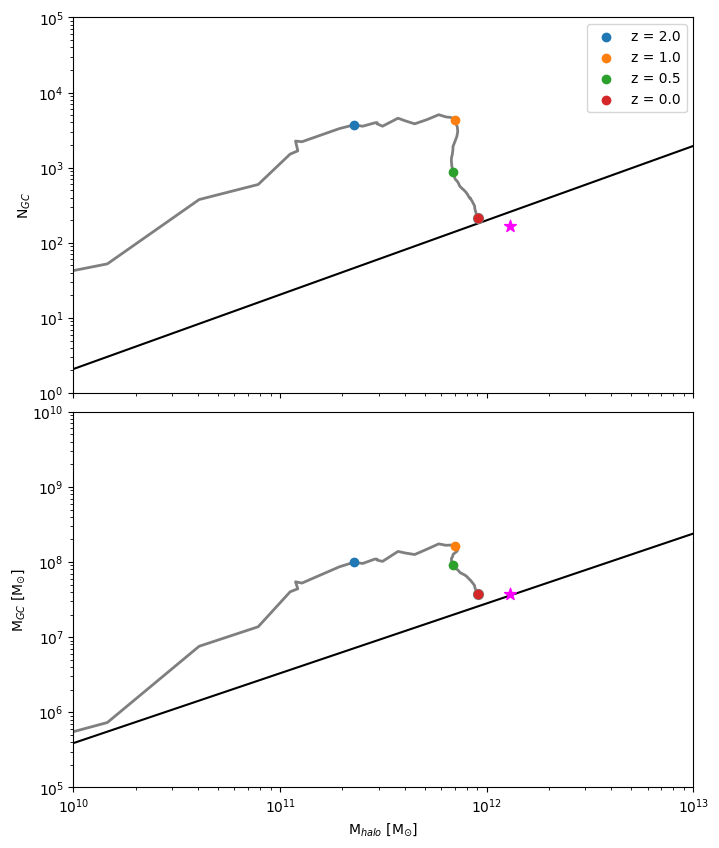

In [14]:
sim = "m12i"

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

tim_z00 = timez0

tim_z100 = 0.488
tim_z050 = 1.209
tim_z050 = 1.209
tim_z020 = 3.372
tim_z010 = 5.988
tim_z005 = 8.708

# plt_tims = {"z = 10": tim_z10, "z = 5": tim_z10, "z = 2": tim_z02}
plt_tims = {"z = 2.0": tim_z020, "z = 1.0": tim_z010, "z = 0.5": tim_z005, "z = 0.0": tim_z00}
plot_gc_cnt(axs[0], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs)
plot_gc_mas(axs[1], sim, tim_z00, sim_halt_dict, sim_colors, mw_gcs)

for lab, tim in plt_tims.items():
    gc_prop_dict = sim_halt_dict[sim]
    # Convert JSON-loaded lists → NumPy arrays
    tim_lst = np.asarray(gc_prop_dict["time"])
    mvirs_all = np.asarray(gc_prop_dict["mvir"])
    gccnts_all = np.asarray(gc_prop_dict["cnt_avg"])
    gcmass_all = np.asarray(gc_prop_dict["mas_avg"])

    tmsk = tim_lst <= tim

    mvir_z = mvirs_all[tmsk][-1]
    gccnts_z = gccnts_all[tmsk][-1]
    gcmass_z = gcmass_all[tmsk][-1]

    axs[0].scatter(mvir_z, gccnts_z, zorder=100, label=lab)
    axs[1].scatter(mvir_z, gcmass_z, zorder=100, label=lab)

axs[0].legend()

# axs[0].set_xlim(10**8)

axs[1].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")
axs[0].set_xticklabels([])

axs[0].set_ylabel(r"N$_{GC}$")
axs[1].set_ylabel(r"M$_{GC}$ [M$_{\odot}$]")

0.03
Plotting sdss_g-sdss_z color
0.01
Plotting sdss_g-sdss_z color
0.09
Plotting sdss_g-sdss_z color
0.0
Plotting sdss_g-sdss_z color

GC colour population is classified as: BIMODAL


(0.0, 60.0)

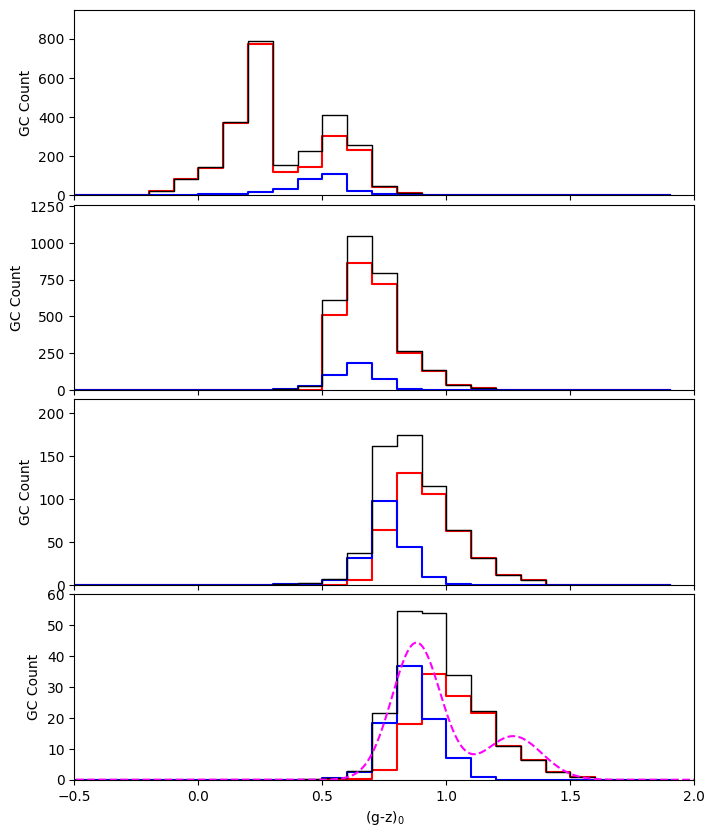

In [15]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-0.5, 2.1, 0.1)
i = 0
for lab, tim in plt_tims.items():
    dif = np.round(np.min(np.abs(tims - tim)), 2)
    print(dif)
    minidx = np.argmin(np.abs(tims - tim))
    mags_hist(axs[i], sim, sim_dict, tims[minidx], tims, bins, bands=["sdss_g", "sdss_z"], origin=True)

    if i == 3:
        axs[i].set_xlabel(r"(g-z)$_{0}$")
    else:
        axs[i].set_xticklabels([])

    i += 1


# MW Overlay
# Ensure cluster_name is string everywhere
for df in (mw_class, mw_gcs, mw_gcs_cols):
    df["cluster_name"] = df["cluster_name"].astype(str)

# Merge Origin from mw_class with V_abs from mw_gcs
df = mw_class.merge(
    mw_gcs[["cluster_name", "V_abs"]],
    on="cluster_name",
    how="inner",
)

# Merge colour columns from mw_gcs_cols
df = df.merge(
    mw_gcs_cols[
        [
            "cluster_name",
            "JC_V-SDSS_g",
            "JC_V-SDSS_z",
        ]
    ],
    on="cluster_name",
    how="inner",
)

mw_v = df["V_abs"]
mw_g = mw_v - df["JC_V-SDSS_g"]
mw_z = mw_v - df["JC_V-SDSS_z"]

dat = mw_g - mw_z

bins = np.arange(-2, 2.1, 0.1)

fd = gaussian_fitting(dat, bins, K_test=[2], BIC_THRESHOLD=6.0)

model_counts = fd["pdf_total"] * fd["bin_width"] * fd["mean_ngc"]

axs[3].plot(fd["x_plot"], model_counts, c="magenta", ls="--")
axs[3].set_ylim(0, 60)

m12i - 3.372 - False
m12i - 5.988 - False
m12i - 8.708 - False
m12i - 13.798746883 - False


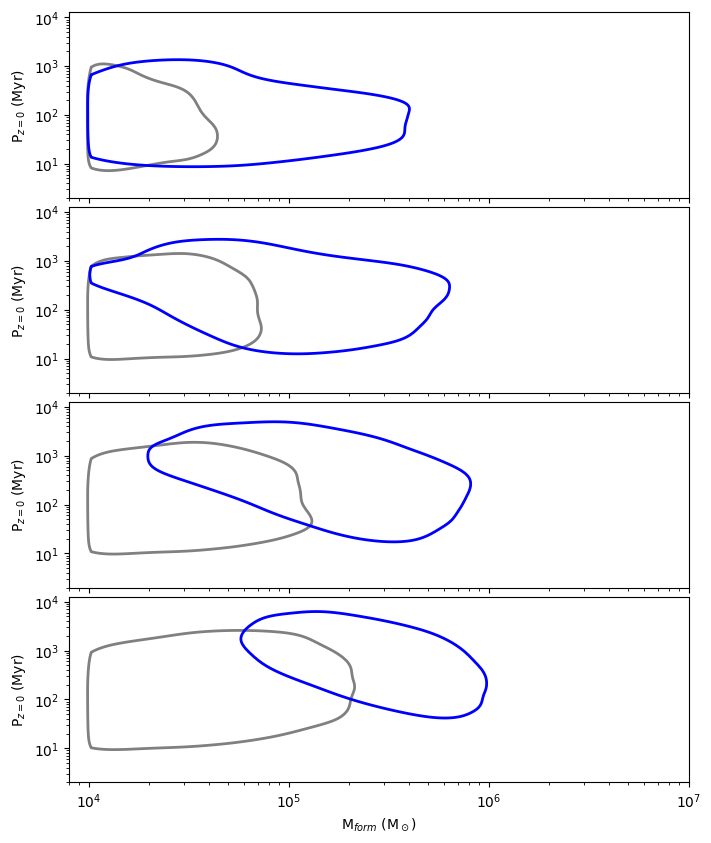

In [16]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

bins = np.arange(-2, 2.1, 0.1)
i = 0
for lab, tim in plt_tims.items():
    # dif = np.round(np.min(np.abs(tims - tim)), 2)
    # print(dif)
    # minidx = np.argmin(np.abs(tims - tim))
    plot_cont_bounding(axs[i], sim, tim, in_msk=False, cont_level=0.95)

    if i == 3:
        continue
    else:
        axs[i].set_xticklabels([])

    i += 1

[Text(100.0, 0, ''),
 Text(1000.0, 0, ''),
 Text(10000.0, 0, ''),
 Text(100000.0, 0, ''),
 Text(1000000.0, 0, ''),
 Text(10000000.0, 0, ''),
 Text(100000000.0, 0, '')]

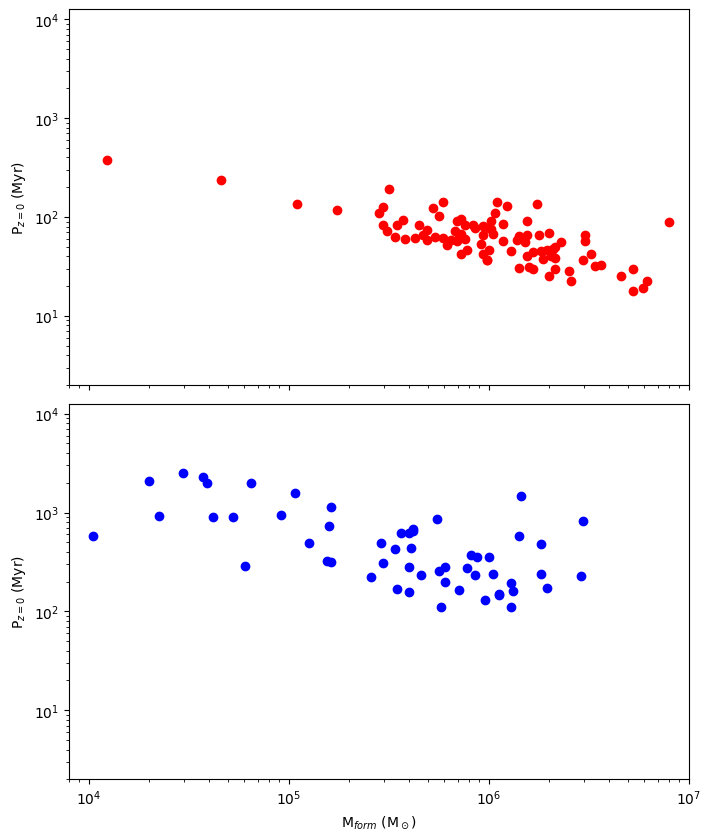

In [17]:
df_orb = mw_gcs.merge(
    mw_class[["cluster_name", "Origin"]],
    on="cluster_name",
    how="inner",
)

torb = df_orb["t_orb"]
mini = 10 ** df_orb["log_mini"]
insitu = df_orb["Origin"] == "in-situ"

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 10))
plt.subplots_adjust(hspace=0.05)

axs[0].scatter(mini[insitu], torb[insitu], c="r")
axs[0].set_xscale("log")
axs[0].set_yscale("log")

axs[1].scatter(mini[~insitu], torb[~insitu], c="b")
axs[1].set_xscale("log")
axs[1].set_yscale("log")

axs[0].set_xlim(10**3.9, 10**7)
axs[0].set_ylim(10**0.3, 10**4.1)

axs[1].set_xlim(10**3.9, 10**7)
axs[1].set_ylim(10**0.3, 10**4.1)

axs[1].set_xlabel(r"$\mathrm{M}_{form}\ (\mathrm{M}_\odot)$")

axs[0].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")
axs[1].set_ylabel(r"$\mathrm{P}_{z=0}$ (Myr)")

axs[0].set_xticklabels([])

In [114]:
np.unique(mw_gcs["class"])

array(['Bulge', 'Disc', 'Halo', 'Unknown'], dtype=object)

In [116]:
torb = df["t_orb"]
mini = 10 ** df["log_mini"]

plt.scatter(mini, torb)
plt.xscale("log")
plt.yscale("log")

KeyError: 't_orb'

# GIF CREATION

Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: TRIMODAL
Plotting v magnitudes
m12m - 13.798746883 - True
m12m - 13.798746883 - False


Text(0.1, 0.75, 'm12m\nt = 13.8 Gyr\nz = 0.0')

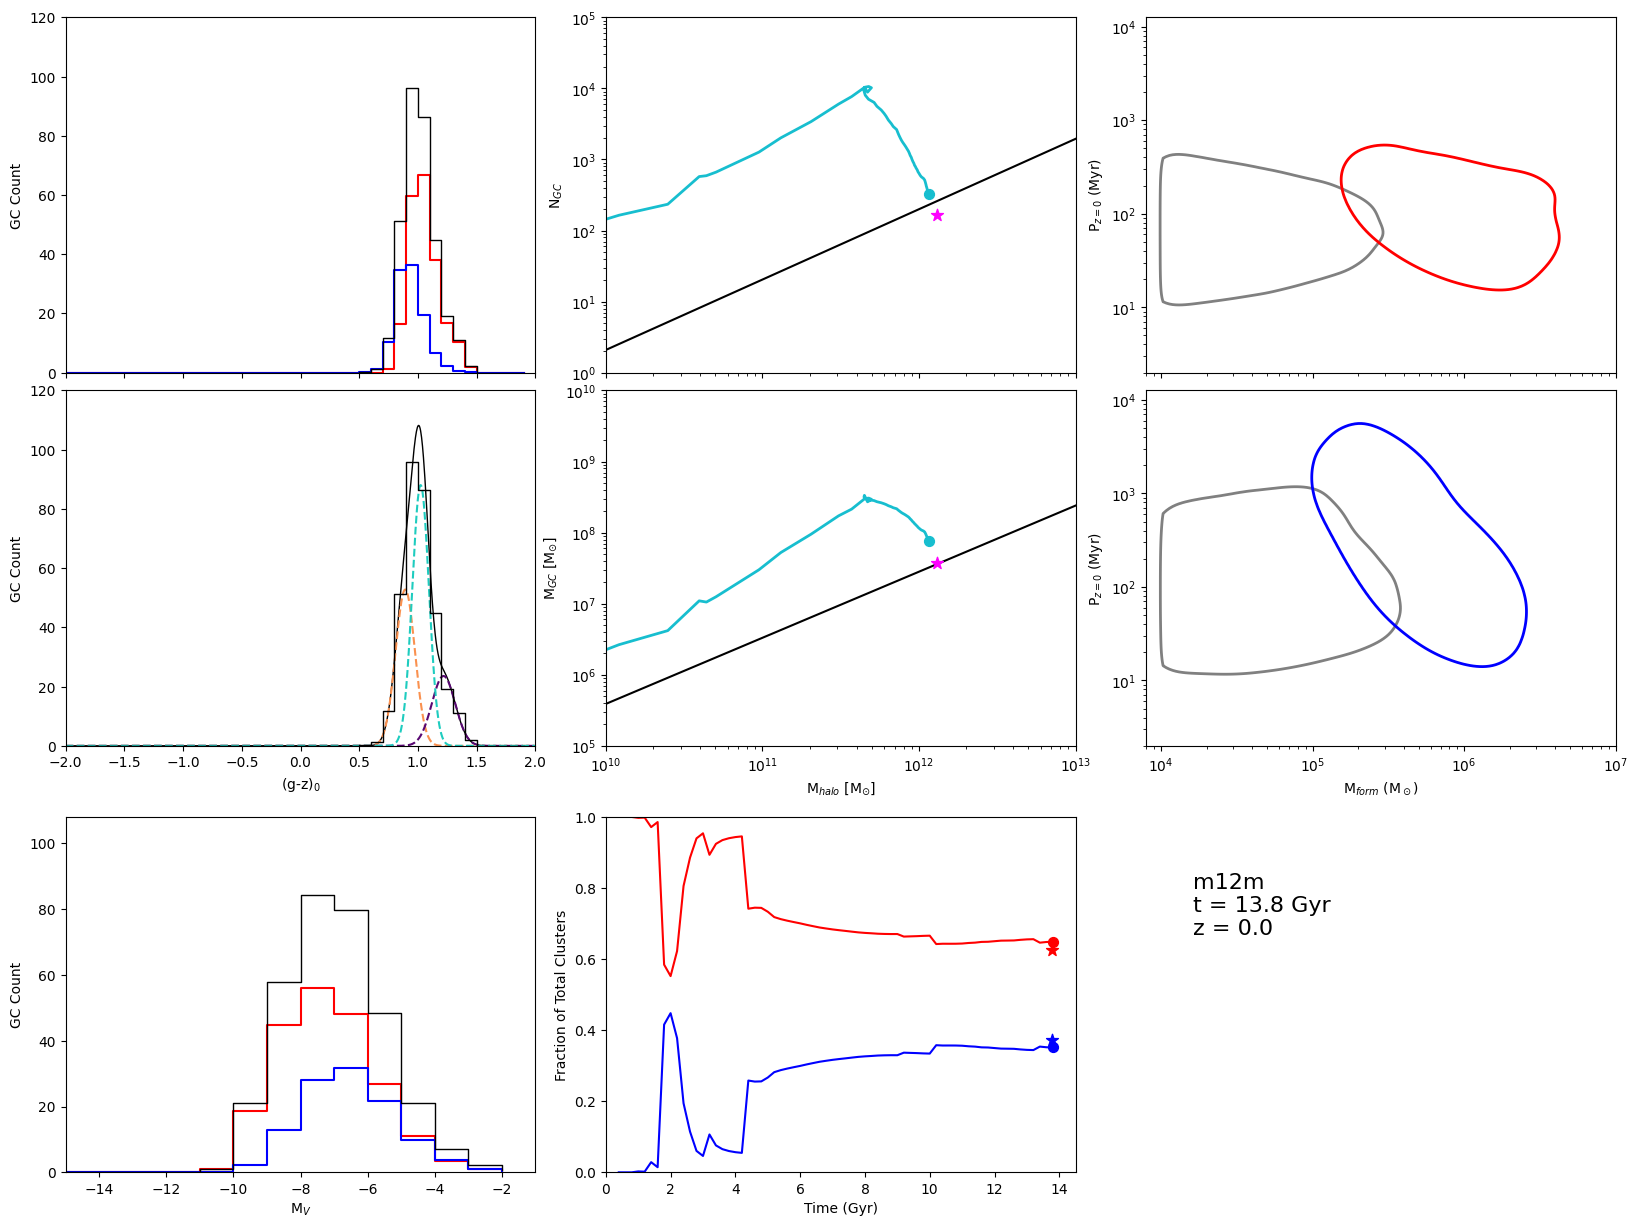

In [14]:
#################################################################

fig = plt.figure(figsize=(20, 15))

# Define adjustable spacings
col_gap_01 = 0.15  # gap between col 0 and 1
col_gap_12 = 0.15  # gap between col 1 and 2
row_gap_01 = 0.05  # gap between row 0 and 1
row_gap_12 = 0.20  # gap between row 1 and 2

gs = GridSpec(
    5,
    5,
    width_ratios=[1, col_gap_01, 1, col_gap_12, 1],
    height_ratios=[1, row_gap_01, 1, row_gap_12, 1],
    wspace=0.0,
    hspace=0.0,
)

axs = [[None] * 3 for _ in range(3)]

for r in range(3):
    for c in range(3):
        axs[r][c] = fig.add_subplot(gs[r * 2, c * 2])

axs[2][2].axis("off")

#################################################################

tim = tims[-1]


# Column 1 #############################################

bins = np.arange(-2, 2.1, 0.1)
mags_hist(axs[0][0], sim, sim_dict, tim, tims, bins, bands=["sdss_g", "sdss_z"], origin=True, plt_text=False)
mags_hist(axs[1][0], sim, sim_dict, tim, tims, bins, bands=["sdss_g", "sdss_z"], gauss_fit=True)

bins = np.arange(-15, 0)
mags_hist(axs[2][0], sim, sim_dict, tim, tims, bins, bands=["v"], origin=True)

axs[0][0].set_xticklabels([])

axs[1][0].set_xlabel(r"(g-z)$_{0}$")
axs[2][0].set_xlabel(r"M$_{V}$")

# Column 2 #############################################

plot_gc_cnt(axs[0][1], sim, tim, sim_halt_dict, sim_colors, mw_gcs)
plot_gc_mas(axs[1][1], sim, tim, sim_halt_dict, sim_colors, mw_gcs)

plot_ratios(axs[2][1], sim, sim_dict, tim, tims, mw_class)

axs[0][1].set_xticklabels([])

axs[1][1].set_xlabel(r"M$_{halo}$ [M$_{\odot}$]")

axs[0][1].set_ylabel(r"N$_{GC}$")
axs[1][1].set_ylabel(r"M$_{GC}$ [M$_{\odot}$]")


# Column 2 #############################################

plot_cont_bounding(axs[0][2], sim, tim, in_msk=True, cont_level=0.95)
plot_cont_bounding(axs[1][2], sim, tim, in_msk=False, cont_level=0.95)

axs[0][2].set_xticklabels([])

if tim > 13.78:
    z = 0
else:
    z = z_at_value(cosmo.age, tim * u.Gyr)

text = sim + "\n" + "t = " + str(np.round(tim, 2)) + " Gyr" + "\n" + "z = " + str(np.round(float(z), 2))
axs[2][2].text(0.1, 0.75, text, ha="left", va="center", transform=axs[2][2].transAxes, fontsize=16)


# GIF IT

In [17]:
def update(tim, sim):

    fig.clear()

    gs = GridSpec(
        5,
        5,
        width_ratios=[1, col_gap_01, 1, col_gap_12, 1],
        height_ratios=[1, row_gap_01, 1, row_gap_12, 1],
        wspace=0.0,
        hspace=0.0,
        figure=fig,
    )

    axs = [[None] * 3 for _ in range(3)]
    for r in range(3):
        for c in range(3):
            axs[r][c] = fig.add_subplot(gs[r * 2, c * 2])

    axs[2][2].axis("off")

    # -------- column 0 --------
    bins = np.arange(-2, 2.1, 0.1)
    mags_hist(
        axs[0][0], sim, sim_dict, tim, tims, bins, bands=["sdss_g", "sdss_z"], origin=True, plt_text=False
    )
    mags_hist(axs[1][0], sim, sim_dict, tim, tims, bins, bands=["sdss_g", "sdss_z"], gauss_fit=True)

    bins = np.arange(-15, 0)
    mags_hist(axs[2][0], sim, sim_dict, tim, tims, bins, bands=["v"], origin=True)

    axs[0][0].set_xticklabels([])
    axs[1][0].set_xlabel(r"(g-z)$_{0}$")
    axs[2][0].set_xlabel(r"M$_V$")

    # -------- column 1 --------
    plot_gc_cnt(axs[0][1], sim, tim, sim_halt_dict, sim_colors, mw_gcs)
    plot_gc_mas(axs[1][1], sim, tim, sim_halt_dict, sim_colors, mw_gcs)
    plot_ratios(axs[2][1], sim, sim_dict, tim, tims, mw_class)

    axs[0][1].set_xticklabels([])
    axs[1][1].set_xlabel(r"M$_{halo}$ [M$_\odot$]")
    axs[0][1].set_ylabel(r"N$_{GC}$")
    axs[1][1].set_ylabel(r"M$_{GC}$ [M$_\odot$]")

    # -------- column 2 --------
    plot_cont_bounding(axs[0][2], sim, tim, in_msk=True, cont_level=0.95)
    plot_cont_bounding(axs[1][2], sim, tim, in_msk=False, cont_level=0.95)
    axs[0][2].set_xticklabels([])

    if tim > 13.78:
        z = 0
    else:
        z = z_at_value(cosmo.age, tim * u.Gyr)

    text = f"{sim}\n t = {tim:.2f} Gyr\n z = {float(z):.2f}"
    axs[2][2].text(0.1, 0.75, text, transform=axs[2][2].transAxes, fontsize=16, ha="left", va="center")

    return []

In [18]:
fig = plt.figure(figsize=(20, 15))

for sim in sim_lst:
    # sim = "m12i"

    anim = FuncAnimation(
        fig,
        update,
        frames=tims[2:],
        fargs=(sim,),
        interval=1000,
        blit=False,
    )

    writer = PillowWriter(fps=1000 // 400)

    gif_loc = "../data/results/" + sim + "_ult.gif"
    anim.save(gif_loc, writer=writer, dpi=150)
    plt.close(fig)

Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: 4-MODAL
Plotting v magnitudes
m12b - 0.8000000000000002 - True
m12b - 0.8000000000000002 - False
Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: 4-MODAL
Plotting v magnitudes
m12b - 0.8000000000000002 - True
m12b - 0.8000000000000002 - False
Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: 4-MODAL
Plotting v magnitudes
m12b - 1.0000000000000002 - True
m12b - 1.0000000000000002 - False
Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: 4-MODAL
Plotting v magnitudes
m12b - 1.2000000000000002 - True
m12b - 1.2000000000000002 - False
Plotting sdss_g-sdss_z color
Plotting sdss_g-sdss_z color

GC colour population is classified as: 4-MODAL
Plotting v magnitudes
m12b - 1.4000000000000004 - True
m12b - 1.4000000000000004 - False
Plotting sdss_g-sdss_z co